# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStasToX)

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

data_path = parent + "/runs/LET_vanad_powder"

with mx.Read(data_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )
display(scipp_data_group)
det_positions = scipp_data_group["positions"]

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 98300}),
    positions: Variable({'pixel_id': 98304}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [2]:
events_binned = scipp_data_group["events"]
display(events_binned)
sample_position = events_binned.coords["sample_position"]

# mask back scattering pixels
# mask = events_binned.coords["position"].fields.z > sample_position.fields.z
# events_binned = events_binned[mask]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98300, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 98302, 98303]
* position                  vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 27.6903), (-2.21669, -1.99219, 27.7086), ..., (2.28249, 1.99219, 22.3467), (2.26071, 1.99219, 22.3281)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 148843119),
          data=float64[counts],
          coords={'t':float64[s]})

In [3]:
with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="Monitor6"
    )

# Read in Monitor data (McStasScript/McStasToX)

In [4]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_single_pulse

mcstas_data = ms.load_data(data_path)
presample_monitor_data = ms.name_search("Monitor6", mcstas_data)
monitor_data = monitor_single_pulse(presample_monitor_data, unit="us")

with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="Monitor6"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:1, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [3.70014]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33629)]
  presample_monitor_position  vector3              [m]  ()  (0, 0, 23.505)
  sample_position           vector3              [m]  ()  (0, 0, 25)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.0280169]
* time_on_sample            float64              [s]  (rrm)  [0.0297938]
  time_on_source            float64              [s]  ()  8e-05
Data:
                            float64         [counts]  (rrm)  [41771.2]

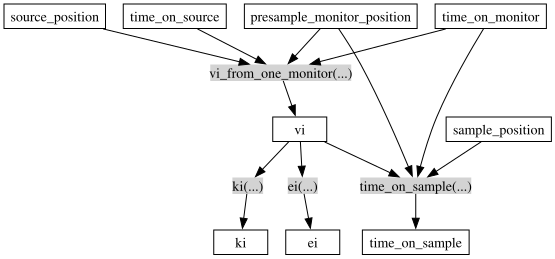

In [5]:
from dgs_reduction import calculate_ei

monitor_data.coords["time_on_source"] = sc.scalar(value=0.08, unit="ms").to(unit="s")

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [6]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98304, rrm:1, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 27.6903), (-2.21669, -1.99219, 27.7086), ..., (2.28249, 1.99219, 22.3467), (2.26071, 1.99219, 22.3281)]
* ei                        float64            [meV]  (rrm)  [3.70014]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33629)]
* monitor_counts            float64         [counts]  (rrm)  [41771.2]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (rrm)  [0.0297938]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.040497, 0.040497, ..., 0.040497, 0.040497]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333616, 0.0333616, ..., 0.0333616, 0.0333616]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [7]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:148843119, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 98303, 98303]
* toa                       float64              [s]  (events)  [0.034565, 0.0345348, ..., 0.0345679, 0.0345685]
Data:
                            float64         [counts]  (events)  [1.04111e-19, 2.81161e-06, ..., 2.9836e-06, 1.5689e-17]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [8]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:148843119, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-2.23877, -1.99219, 27.6903), (-2.23877, -1.99219, 27.6903), ..., (2.26071, 1.99219, 22.3281), (2.26071, 1.99219, 22.3281)]
* ei                        float64            [meV]  (events)  [3.70014, 3.70014, ..., 3.70014, 3.70014]
* ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33629), (0, 0, 1.33629), ..., (0, 0, 1.33629), (0, 0, 1.33629)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 98303, 98303]
* rrm                         int64  [dimensionless]  (events)  [0, 0, ..., 0, 0]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (events)  [0.0297938, 0.0297938, ..., 0.0297938, 0.0297938]
* toa                       float64              [s]  (events)  [0.034565, 0.0345348, ..., 0.0345679, 0.0345685]
Data:
                            float64         [counts]  (events)  [1.04111e-19, 2.81161e-06, ..., 2.9836e-06, 1.5689e-17]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:148843119, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-2.23877, -1.99219, 27.6903), (-2.23877, -1.99219, 27.6903), ..., (2.26071, 1.99219, 22.3281), (2.26071, 1.99219, 22.3281)]
  ef                        float64            [meV]  (events)  [3.72417, 3.7717, ..., 3.71966, 3.71859]
  ei                        float64            [meV]  (events)  [3.70014, 3.70014, ..., 3.70014, 3.70014]
* en                        float64            [meV]  (events)  [-0.0240283, -0.0715584, ..., -0.0195217, -0.0184481]
* kf                        vector3           [1/Å]  (events)  [(-0.745258, -0.663174, 0.895579), (-0.749999, -0.667393, 0.901276), ..., (0.752105, 0.662773, -0.888914), (0.751996, 0.662677, -0.888785)]
  ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33629), (0, 0, 1.33629), ..., (0, 0, 1.33629), (0, 0, 1.33629)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 98303, 98303]
  q                         vector3           [1/Å]  (events)  [(0.745258, 0.663174, 0.440713), (0.749999, 0.667393, 0.435016), ..., (-0.752105, -0.662773, 2.22521), (-0.751996, -0.662677, 2.22508)]
* q_mag                     float64           [1/Å]  (events)  [1.09061, 1.09414, ..., 2.44059, 2.44041]
* qx                        float64           [1/Å]  (events)  [0.745258, 0.749999, ..., -0.752105, -0.751996]
* qy                        float64           [1/Å]  (events)  [0.663174, 0.667393, ..., -0.662773, -0.662677]
* qz                        float64           [1/Å]  (events)  [0.440713, 0.435016, ..., 2.22521, 2.22508]
* rrm                         int64  [dimensionless]  (events)  [0, 0, ..., 0, 0]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  time_on_sample            float64              [s]  (events)  [0.0297938, 0.0297938, ..., 0.0297938, 0.0297938]
  toa                       float64              [s]  (events)  [0.034565, 0.0345348, ..., 0.0345679, 0.0345685]
  vf                        vector3            [m/s]  (events)  [(-469.231, -417.549, 563.877), (-472.216, -420.205, 567.463), ..., (473.542, 417.297, -559.68), (473.474, 417.236, -559.599)]
Data:
                            float64         [counts]  (events)  [1.04111e-19, 2.81161e-06, ..., 2.9836e-06, 1.5689e-17]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

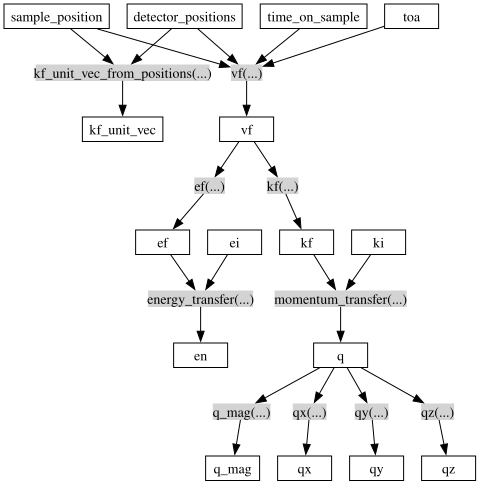

In [9]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [10]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

parent = os.path.dirname(os.getcwd())
van_path = parent + "/runs/LET_vanad_powder"

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
sample_position = v_events_binned.coords["sample_position"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98300, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 98302, 98303]
* position                  vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 27.6903), (-2.21669, -1.99219, 27.7086), ..., (2.28249, 1.99219, 22.3467), (2.26071, 1.99219, 22.3281)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 148843119),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98304, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 98302, 98303]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 148843119),
          data=float64[counts],
          coords={'t':float64[s]})

# Mask the leakage from beamstop

In [11]:
import numpy as np
# solid angles
# LET banana detectors
# Horizontal -40 to 140 degs, sample to detector distance is R = 3.5 m, 221 bins
# width per pixel is w = (140+40)/180*pi*R/384 =  0.02863 m
# Vertical height is H = 4 m, 256 bins
# height per pixel is h = H/256 = 0.015625 m
# height per pixel is h = H/136 = 0.0294 m
# solid angle Omega = 4*arctan(w*h/(2d*sqrt(4d^2+w^2+h^2)))
# d = sqrt(x^2+y^2+z^2)

d_omega_exp = v_events.hist().data
mask = d_omega_exp > sc.scalar(0.0015, unit=d_omega_exp.unit)
d_omega_exp = sc.where(mask, sc.scalar(np.nan, unit=d_omega_exp.unit), d_omega_exp)

d_omega_exp /= d_omega_exp.nansum()
print(d_omega_exp)
# norm_factors.coords["d_omega_exp"] = d_omega

<scipp.Variable> (pixel_id: 98304)    float64  [dimensionless]  [7.87676e-06, 7.80256e-06, ..., 8.24007e-06, 7.98841e-06]


<scipp.DataArray>
Dimensions: Sizes[pixel_id:98304, ]
Coordinates:
  detector_geometry          string        <no unit>  ()  "cylinder"
  pixel_height              float64              [m]  ()  0.015625
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 98302, 98303]
  pixel_position            vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 2.69034), (-2.21669, -1.99219, 2.70856), ..., (2.28249, 1.99219, -2.65335), (2.26071, 1.99219, -2.67193)]
* pixel_solid_angle         float64             [sr]  (pixel_id)  [2.39741e-05, 2.39741e-05, ..., 2.39741e-05, 2.39741e-05]
  pixel_width               float64              [m]  ()  0.0286342
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 148843119),
          data=float64[counts],
          coords={'t':float64[s]})

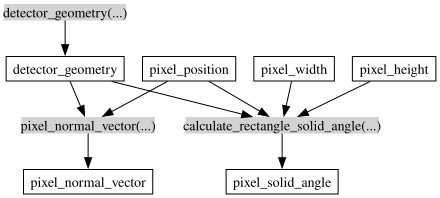

In [12]:
from reduction.dgs_reduction import calculate_solid_angle

h = sc.norm(detector_posisitions[384] - detector_posisitions[0])
w = sc.norm(detector_posisitions[1] - detector_posisitions[0])
r = detector_posisitions - sample_position

v_events.coords["pixel_position"] = r
v_events.coords["pixel_height"] = h
v_events.coords["pixel_width"] = w
v_events = v_events.transform_coords(
    [
        "pixel_solid_angle",
    ],
    graph=calculate_solid_angle,
)
display(v_events)
sc.show_graph(calculate_solid_angle)

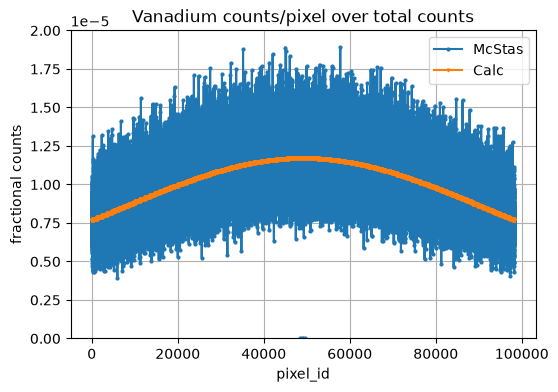

In [13]:
import plopp as pp

pp.plot(
    {
        "McStas": d_omega_exp,
        "Calc": v_events.coords["pixel_solid_angle"]
        / sc.sum(v_events.coords["pixel_solid_angle"]),
    },
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    linestyle="-",
    markersize=2,
    ymax=2e-5,
    ymin=0.0,
    grid=True,
)

In [14]:
norm_factors.coords["d_omega"] = v_events.coords["pixel_solid_angle"]
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98304, rrm:1, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [2.39741e-05, 2.39741e-05, ..., 2.39741e-05, 2.39741e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 27.6903), (-2.21669, -1.99219, 27.7086), ..., (2.28249, 1.99219, 22.3467), (2.26071, 1.99219, 22.3281)]
* ei                        float64            [meV]  (rrm)  [3.70014]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33629)]
* monitor_counts            float64         [counts]  (rrm)  [41771.2]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (rrm)  [0.0297938]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.040497, 0.040497, ..., 0.040497, 0.040497]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333616, 0.0333616, ..., 0.0333616, 0.0333616]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:98304, rrm:1, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [2.39741e-05, 2.39741e-05, ..., 2.39741e-05, 2.39741e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-2.23877, -1.99219, 27.6903), (-2.21669, -1.99219, 27.7086), ..., (2.28249, 1.99219, 22.3467), (2.26071, 1.99219, 22.3281)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [6.66026, 6.66026, ..., 6.66026, 6.66026]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [0.740029, 0.740029, ..., 0.740029, 0.740029]
  ei                        float64            [meV]  (rrm)  [3.70014]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.996638, -0.886866, 1.19766), (-0.986807, -0.886866, 1.20578), ..., (1.0161, 0.886866, -1.1812), (1.0064, 0.886866, -1.18947)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [1.79282, 1.79282, ..., 1.79282, 1.79282]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.332213, -0.295622, 0.399221), (-0.328936, -0.295622, 0.401925), ..., (0.3387, 0.295622, -0.393732), (0.335468, 0.295622, -0.39649)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [0.597608, 0.597608, ..., 0.597608, 0.597608]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.555904, -0.494676, 0.668032), (-0.55042, -0.494676, 0.672557), ..., (0.56676, 0.494676, -0.658847), (0.561351, 0.494676, -0.663461)]
  ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33629)]
* monitor_counts            float64         [counts]  (rrm)  [41771.2]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(0.996638, 0.886866, 0.138629), (0.986807, 0.886866, 0.130515), ..., (-1.0161, -0.886866, 2.51749), (-1.0064, -0.886866, 2.52576)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(0.332213, 0.295622, 0.937071), (0.328936, 0.295622, 0.934366), ..., (-0.3387, -0.295622, 1.73002), (-0.335468, -0.295622, 1.73278)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  time_on_sample            float64              [s]  (rrm)  [0.0297938]
  toa_max                   float64              [s]  (pixel_id, rrm)  [0.040497, 0.040497, ..., 0.040497, 0.040497]
  toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333616, 0.0333616, ..., 0.0333616, 0.0333616]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

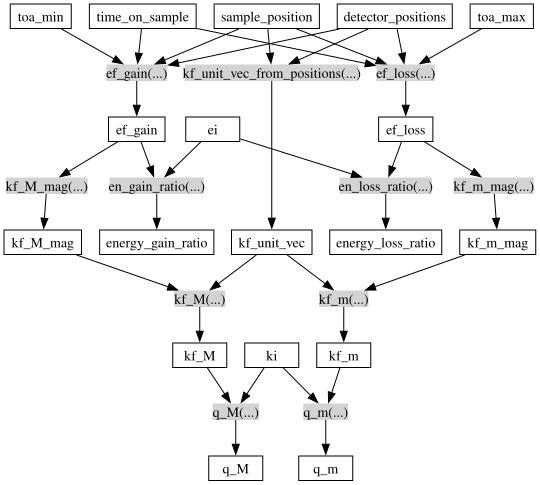

In [15]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

# Plot |Q| vs. E for powder samples

In [16]:
from dgs_reduction import mdnorm

rrm = 0
grid = {
    "qx": (-2.5, 2.0, 0.1),
    "qy": (-2.0, 2.0, 0.1),
    "qz": (-1.5, 2.5, 0.1),
    "en": (-4, 4, 0.005),
}

data4d, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

mag_q = sc.sqrt(
    sc.midpoints(data4d.coords["qx"]) ** 2
    + sc.midpoints(data4d.coords["qy"]) ** 2
    + sc.midpoints(data4d.coords["qz"]) ** 2
)

data4d.coords["mag_q"] = mag_q
data4d

<scipp.DataArray>
Dimensions: Sizes[en:1600, qz:40, qy:40, qx:45, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (qx, qy, qz)  [3.45072, 3.40991, ..., 3.62319, 3.68883]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2.5, -2.4, ..., 1.9, 2]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1.5, -1.4, ..., 2.4, 2.5]
Data:
                            float64       [1/sr/meV]  (en, qz, qy, qx)  [nan, nan, ..., nan, nan]

In [17]:
q_bins = sc.linspace("mag_q", 0.0, 3.0, num=100, unit="1/Å")
rebinned = data4d.bin(mag_q=q_bins)
data_rebinned = rebinned.bins.nanmean()
display(data_rebinned)

<scipp.DataArray>
Dimensions: Sizes[en:1600, mag_q:99, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (mag_q [bin-edge])  [0, 0.030303, ..., 2.9697, 3]
Data:
                            float64       [1/sr/meV]  (en, mag_q)  [nan, nan, ..., nan, nan]

In [18]:
R = sc.scalar(3.5, unit="m")  # sample to detector
r = sc.scalar(0.012, unit="m")  # radius of sample


def actual_path(two_theta):
    return sc.sqrt(R**2 + r**2 + 2 * R * r * sc.cos(two_theta))


ei = sc.scalar(3.705, unit="meV")
ki = sc.scalar(1.337169, unit="Å^-1")
two_theta = sc.arange(dim="two_theta", start=0.0, stop=2 * np.pi, step=0.1, unit="rad")


en = ei * (1 - (R / (actual_path(two_theta) - r)) ** 2)
ratio = R / (actual_path(two_theta) - r)
q_mag = ki * sc.sqrt(
    ratio**2 * sc.sin(two_theta) ** 2 + (1 - ratio * sc.cos(two_theta)) ** 2
)

# pp.plot(sc.DataArray(data=en, coords={"q_mag": q_mag}))

In [26]:
fig = pp.scatter(
    sc.DataArray(data=two_theta, coords={"q_mag": q_mag, "en": en}),
    x="q_mag",
    y="en",
    color="w",
)

pp.plot(
    data_rebinned,
    grid=True,
    ax=fig.ax,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…